In [23]:
import pandas as pd
from seaborn import lineplot

from visualisierungen import *

In [24]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr             rechtsform_name  \
0  1.0  1848-09-12  1848-1851  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  berecht  ...  zustimmung_p-vdk  zustimmung_p-sodk  \
0      1.0        72.83      NaN  ...               NaN                NaN   
1      0.0    

# Postion-Bundesrat vs. Zustimmung

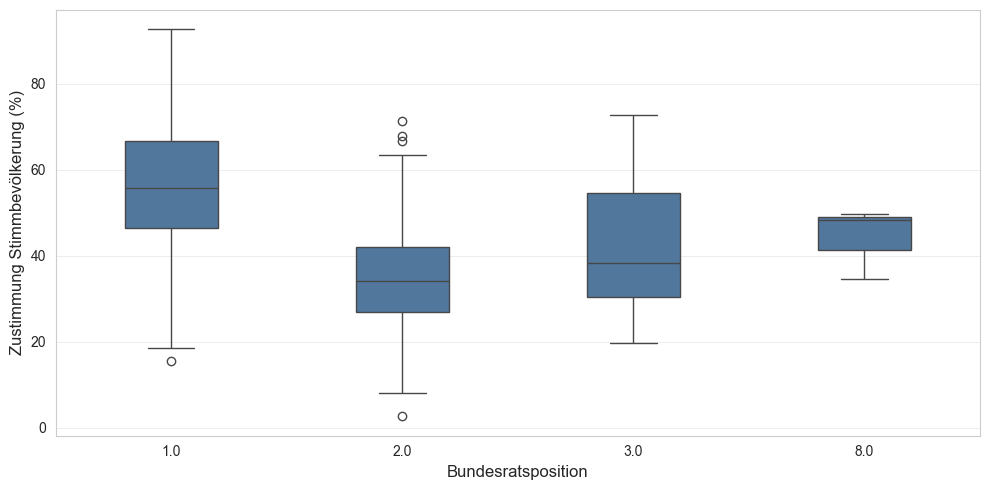

In [25]:
boxplot(df, df["br-pos"], df["volkja-proz"], titel="", xlabel="Bundesratsposition", ylabel="Zustimmung Stimmbevölkerung (%)", farbe=None)


# Zeitliche Dimension

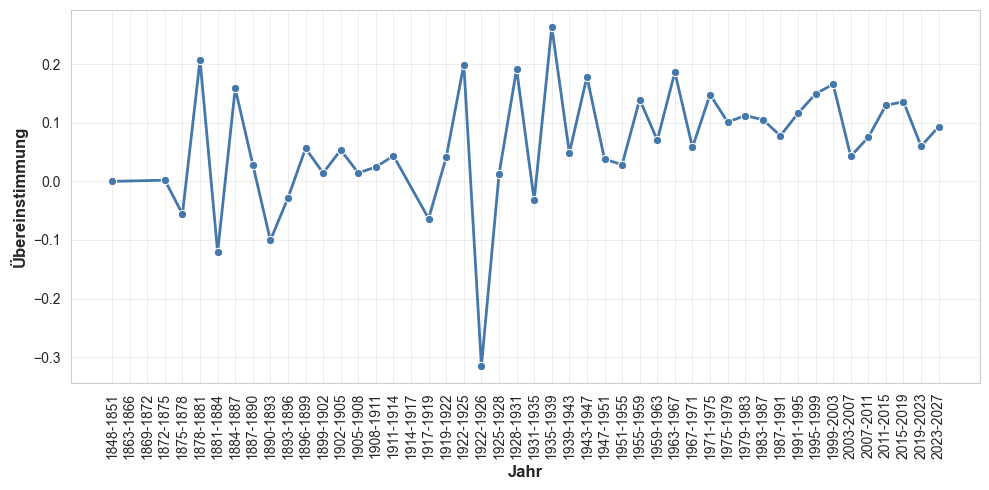

In [26]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:317: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


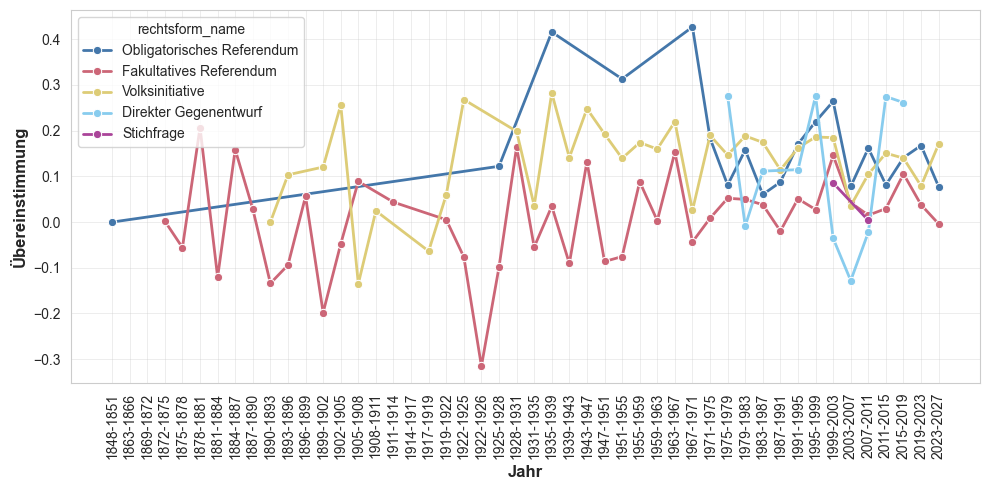

In [27]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, hue="rechtsform_name", errorbar=None)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:317: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


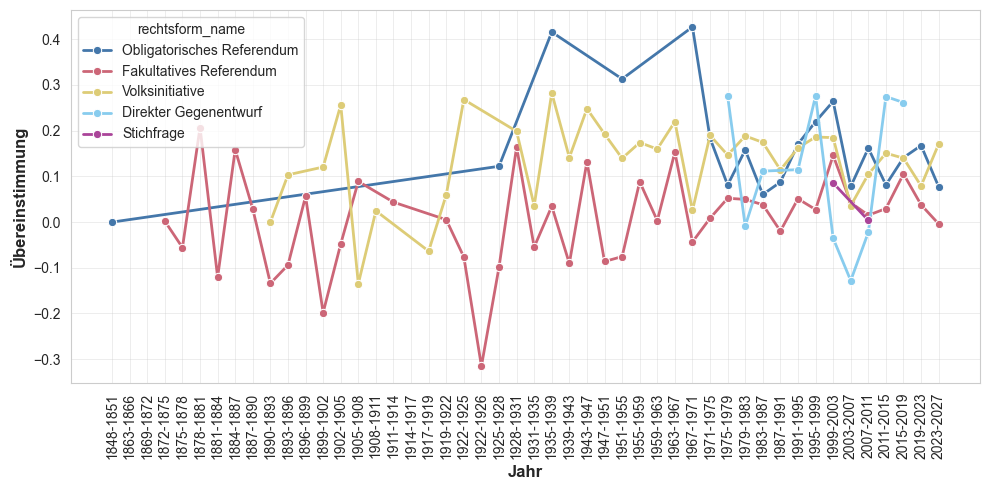

In [28]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, hue="rechtsform_name", errorbar=None)

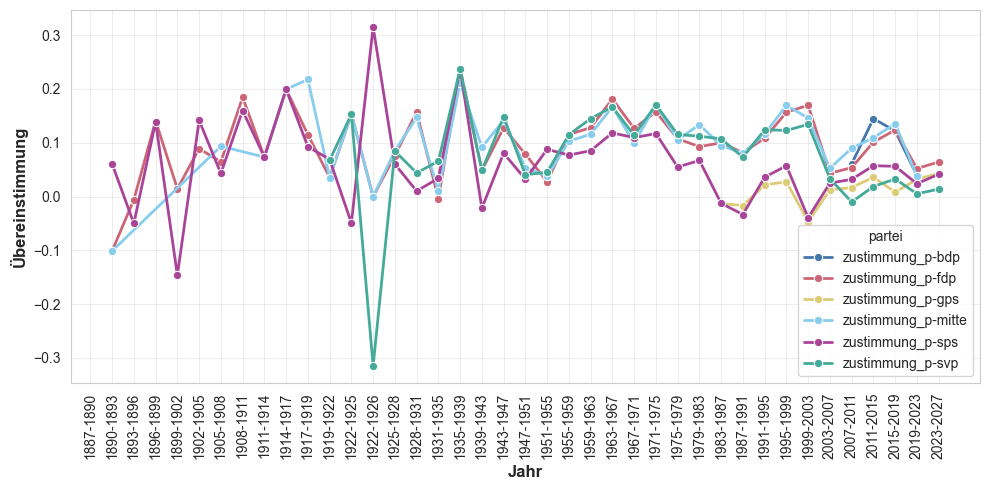

In [30]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte","zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"]

df_long = df[["legisjahr"] + partei_cols].melt(
    id_vars="legisjahr", var_name="partei", value_name="zustimmung")

df_long_mean = df_long.groupby(["legisjahr", "partei"])["zustimmung"].mean().reset_index()

liniendiagramm(df_long_mean, x="legisjahr", y="zustimmung", hue="partei",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90)